### Hands-on Lab: Generative AI for Data Insights
One of the principal steps in understanding and interpreting data is drawing statistical and correlative insights from the data. In this lab, you will learn how to use efficient prompts on a Generative AI platform to create a Python script for generating insights on a data set available in a CSV file.

## Objectives
In this lab, you will learn how to create prompts to generate Python code that can:

Generate a statistical description of all the features of the data set
Generate regression and box plots for different attributes to compare their distribution against a target attribute
Evaluate the correlation value, Pearson coefficient, and p-values for different parameters of the data set with the target parameter
Create pivot tables for a group of parameters and visualize them using pcolor plots
Data set
  




  
For this lab, you'll use a clean version of a publically available data set about laptop price prediction using specifications.

The CSV file for this clean version of the data set is available at the following URL:



In [3]:

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"


### Reading the data set and generating the statistical description

First, you must import the data set into the interface as a pandas data frame. To complete the first objective, you can further generate a statistical description of the data set.

The data set is now assumed to be completely prepared and ready for exploratory data analysis. The headers for the data set must be in the first row of the CSV file.

To read the CSV file to a data frame and a generate statistical description of the data set, provide the generative AI model with the following prompt.

You can set the prompt like below to get a defined output:


Now you can run the following in the type your message section and start the chat.

Write a python code to perform the following actions.
1. Import a data set from a CSV file, The headers for the data set must be in the first row of the CSV file.
2. Generate the statistical description of all the features used in the data set. Include "object" data types as well.

In [7]:
# This script reads a CSV file named data.csv with headers in the first row, creates a DataFrame, computes descriptive statistics for all columns (including object dtype) using describe(include='all'), and prints the result.

import pandas as pd

# Read the CSV file into a DataFrame. Assumes the first row contains headers.
df = pd.read_csv(URL)

# Generate descriptive statistics for all columns, including object (categorical) types.
description = df.describe(include="all")

# Output the description to stdout
print(description)

        Unnamed: 0.1  Unnamed: 0 Manufacturer    Category         GPU  \
count     238.000000  238.000000          238  238.000000  238.000000   
unique           NaN         NaN           11         NaN         NaN   
top              NaN         NaN         Dell         NaN         NaN   
freq             NaN         NaN           71         NaN         NaN   
mean      118.500000  118.500000          NaN    3.205882    2.151261   
std        68.848868   68.848868          NaN    0.776533    0.638282   
min         0.000000    0.000000          NaN    1.000000    1.000000   
25%        59.250000   59.250000          NaN    3.000000    2.000000   
50%       118.500000  118.500000          NaN    3.000000    2.000000   
75%       177.750000  177.750000          NaN    4.000000    3.000000   
max       237.000000  237.000000          NaN    5.000000    3.000000   

                OS    CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
count   238.000000  238.000000        238.00

### Creating parameter visualizations
Next, you decided that you need to see the distribution of various attributes against the target attribute. The target attribute, in this case, is Price. Different forms of visualizations are for different types of attributes. Attributes with continuous values use regression plots, and the attributes with categorical values use box plots.
You can provide the generative AI model with a list of continuous values and another list of categorical values within a single prompt and ask the model to create a code that generates these plots.

The attributes with continuous values are CPU_frequency, Screen_Size_inch and Weight_pounds.
The attributes with categorical values are Category, GPU, OS, CPU_core, RAM_GB and Storage_GB_SSD.

Create the following prompt:

Write a Python code to perform the following actions.
1. Create regression plots for the attributes "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price".
2. Create box plots for the attributes "Category", "GPU", "OS", "CPU_core", "RAM_GB" and "Storage_GB_SSD" against the attribute "Price".


The output should be as shown below.

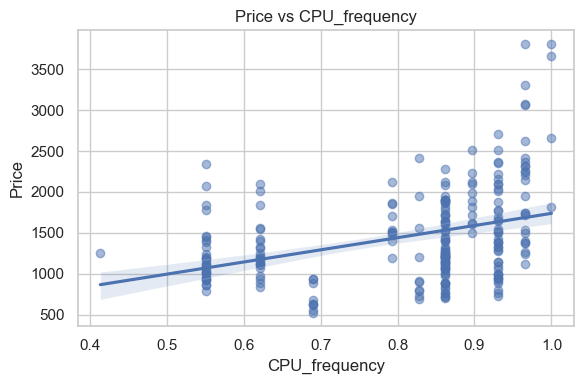

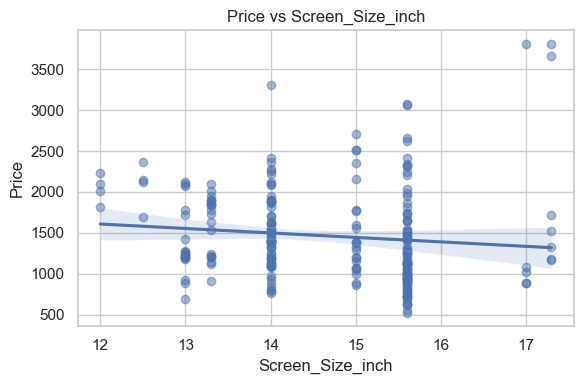

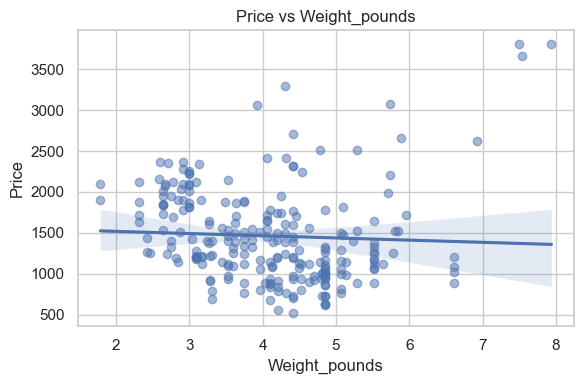

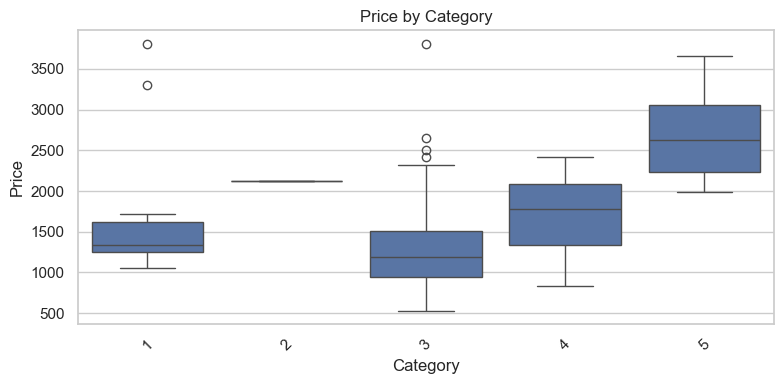

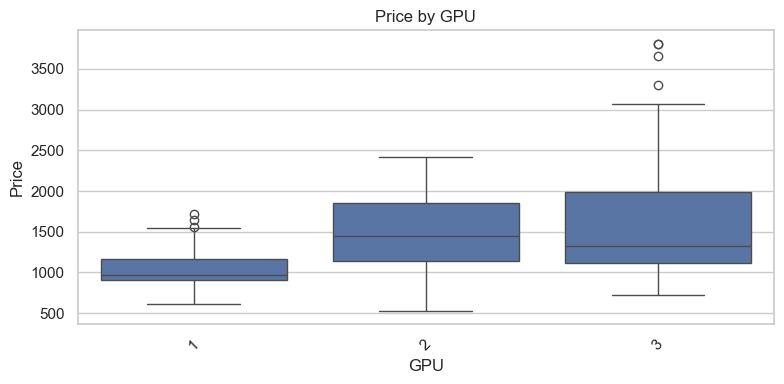

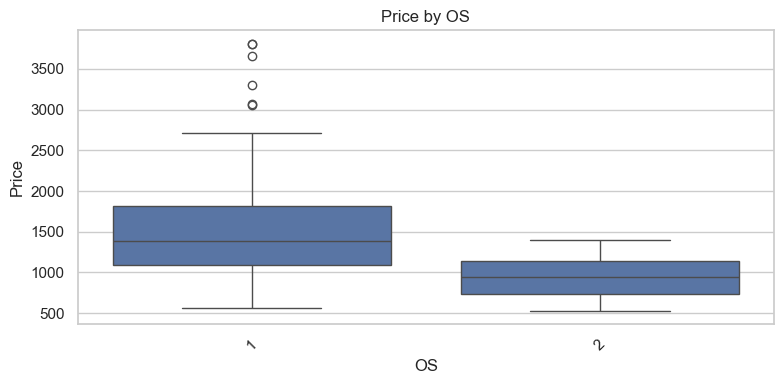

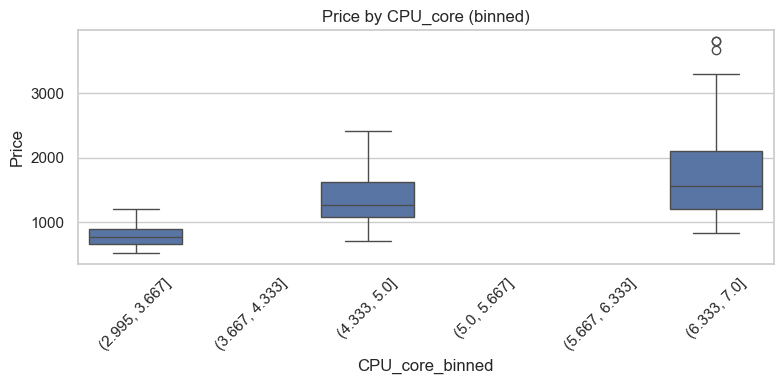

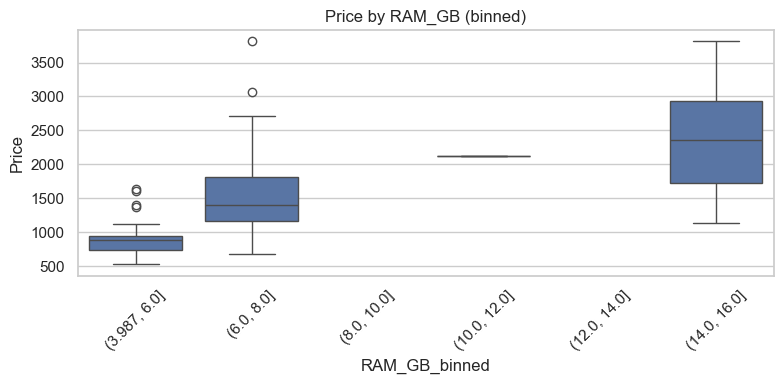

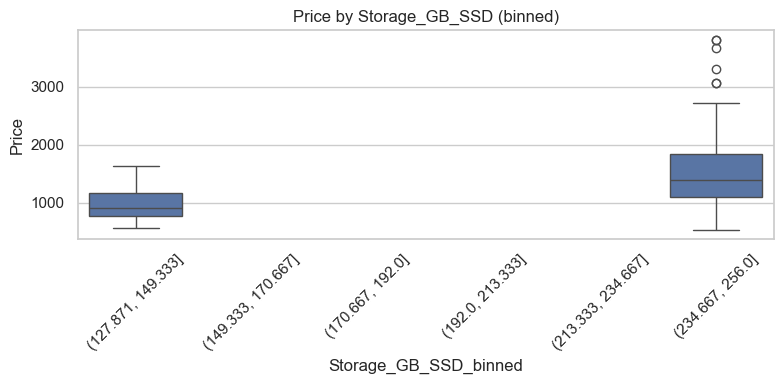

In [10]:
# This script generates regression plots of Price against CPU_frequency, Screen_Size_inch, and Weight_pounds, followed by box plots of Price by several attributes. For numeric attributes CPU_core, RAM_GB, and Storage_GB_SSD, it creates evenly spaced bins to produce interpretable box plots. Assumes input data is in data.csv with the specified columns.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset from CSV (expects columns: Price, CPU_frequency, Screen_Size_inch, Weight_pounds,
# Category, GPU, OS, CPU_core, RAM_GB, Storage_GB_SSD)

# Set Seaborn aesthetics
sns.set(style='whitegrid')

# Regression plots: Price vs numeric attributes
plt.figure(figsize=(6, 4))
sns.regplot(x='CPU_frequency', y='Price', data=df, scatter_kws={'alpha': 0.5})
plt.title('Price vs CPU_frequency')
plt.xlabel('CPU_frequency')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(x='Screen_Size_inch', y='Price', data=df, scatter_kws={'alpha': 0.5})
plt.title('Price vs Screen_Size_inch')
plt.xlabel('Screen_Size_inch')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(x='Weight_pounds', y='Price', data=df, scatter_kws={'alpha': 0.5})
plt.title('Price vs Weight_pounds')
plt.xlabel('Weight_pounds')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Box plots: Price by categorical attributes
plt.figure(figsize=(8, 4))
sns.boxplot(x='Category', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by Category')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='GPU', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by GPU')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='OS', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by OS')
plt.tight_layout()
plt.show()

# For numeric attributes, create bins to enable box plots against Price
df['CPU_core_binned'] = pd.cut(df['CPU_core'], bins=6, include_lowest=True)
plt.figure(figsize=(8, 4))
sns.boxplot(x='CPU_core_binned', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by CPU_core (binned)')
plt.tight_layout()
plt.show()

df['RAM_GB_binned'] = pd.cut(df['RAM_GB'], bins=6, include_lowest=True)
plt.figure(figsize=(8, 4))
sns.boxplot(x='RAM_GB_binned', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by RAM_GB (binned)')
plt.tight_layout()
plt.show()

df['Storage_GB_SSD_binned'] = pd.cut(df['Storage_GB_SSD'], bins=6, include_lowest=True)
plt.figure(figsize=(8, 4))
sns.boxplot(x='Storage_GB_SSD_binned', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by Storage_GB_SSD (binned)')
plt.tight_layout()
plt.show()

### Evaluate dependence
Usually, not all parameters in a data set have a direct or strong level of influence on the target variable. The level of influence is especially important for data scientists because the design of predictive models uses variables that affect the target variable the most.

To evaluate parametric interdependence, one can evaluate the correlation value, the Pearson coefficient, and p-values of different attributes with the target attribute.

Use the following prompt to write a prompt to evaluate dependence:


Write a Python code for the following.
1. Evaluate the correlation value, pearson coefficient and p-values for all numerical attributes against the target attribute "Price".
2. Don't include the values evaluated for target variable against itself.
3. Print these values as a part of a single dataframe against each individual attribute.

You can view the output for this prompt below.

In [13]:
# Loads data from data.csv, finds numeric feature columns, excludes the target Price, and for each numeric attribute computes the Pearson correlation coefficient (r) and its p-value with Price. The results are assembled into a single dataframe with one row per attribute and columns: Pearson_r, Correlation (same as Pearson_r), and p_value.

import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Load dataset (expects a column named 'Price' and numeric feature columns)
# df = pd.read_csv('data.csv')

# Identify numeric attributes and exclude the target 'Price'
numeric_cols = df.select_dtypes(include=[np.number]).columns
attributes = [col for col in numeric_cols if col != 'Price']

# Compute Pearson r and p-value for each numeric attribute against Price
results = []
for attr in attributes:
    sub = df[[attr, 'Price']].dropna()
    r, p = pearsonr(sub[attr], sub['Price'])
    results.append({'Attribute': attr, 'Pearson_r': r, 'Correlation': r, 'p_value': p})

# Present as a single dataframe with one row per attribute
result_df = pd.DataFrame(results).set_index('Attribute')
print(result_df)

                  Pearson_r  Correlation       p_value
Attribute                                             
Unnamed: 0.1       0.321933     0.321933  3.851058e-07
Unnamed: 0         0.321933     0.321933  3.851058e-07
Category           0.286243     0.286243  7.225696e-06
GPU                0.288298     0.288298  6.166950e-06
OS                -0.221730    -0.221730  5.696643e-04
CPU_core           0.459398     0.459398  7.912950e-14
Screen_Size_inch  -0.110644    -0.110644  8.853398e-02
CPU_frequency      0.366666     0.366666  5.502463e-09
RAM_GB             0.549297     0.549297  3.681561e-20
Storage_GB_SSD     0.243421     0.243421  1.489892e-04
Weight_pounds     -0.050312    -0.050312  4.397694e-01
Screen-Full_HD    -0.021075    -0.021075  7.463568e-01
Screen-IPS_panel   0.021075     0.021075  7.463568e-01


### Grouping and pivots
You can perform another form of exploratory data analysis by grouping different variables to create a pivot table, which serves as a matrix of different combinations of values as seen in the grouped variables. The respective value of the matrix is the average of all values of the target attribute that have the same combination. You can view this kind of matrix using a pcolor plot.

Say you need to create a group with parameters GPU, CPU_core and Price. You need a Pivot table, considering Price as the target variable and pcolor plot for that table.

You can follow the following prompt as an example:

Write a python code that performs the following actions.
1. Group the attributes "GPU", "CPU_core" and "Price", as available in a dataframe df
2. Create a pivot table for this group, assuming the target variable to be 'Price' and aggregation function as mean
3. Plot a pcolor plot for this pivot table.


You can see the output for this prompt below.

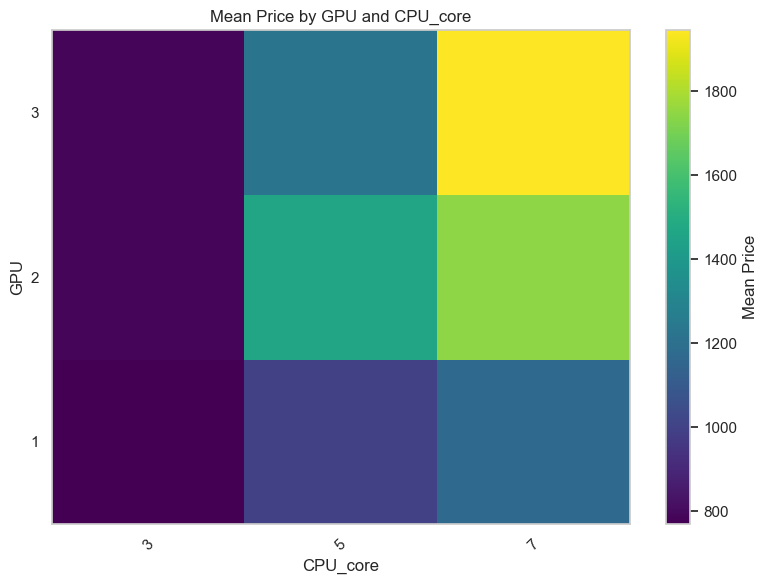

In [18]:
# Conclusion
Congratulations! You have completed this lab about generating data insights using generative AI tools.

Now you should be able to build efficient and helpful prompts that can create code to:

Generate statistical descriptions of the data
Create visualizations, such as regression plots and box plots, to understand the distribution of the data set against the target variable
Evaluate the dependence of different attributes against the target attribute
Group different variables to create a pivot table and visualize the data using a pcolor plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assumes df contains the columns: GPU, CPU_core, and Price
# Create a pivot table grouping by GPU (rows) and CPU_core (columns) with mean Price
pivot = df.pivot_table(values='Price', index='GPU', columns='CPU_core', aggfunc='mean')

# Plot a pcolor heatmap of the pivot table
plt.figure(figsize=(8, 6))
pc = plt.pcolor(pivot.values, cmap='viridis')
plt.colorbar(pc, label='Mean Price')
plt.xlabel('CPU_core')
plt.ylabel('GPU')
plt.title('Mean Price by GPU and CPU_core')

# Set axis tick labels
plt.xticks(np.arange(0.5, len(pivot.columns), 1), pivot.columns, rotation=45)
plt.yticks(np.arange(0.5, len(pivot.index), 1), pivot.index)
plt.tight_layout()
plt.show()

### Conclusion
Congratulations! You have completed this lab about generating data insights using generative AI tools.

Now you should be able to build efficient and helpful prompts that can create code to:

Generate statistical descriptions of the data
Create visualizations, such as regression plots and box plots, to understand the distribution of the data set against the target variable
Evaluate the dependence of different attributes against the target attribute
Group different variables to create a pivot table and visualize the data using a pcolor plot